# Results (clean) — paper §4 headline figures

One figure per research question. All metrics swept across all 8 saved layers. No focal-layer picks, no per-framework file splits.

| Fig | § | Claim |
|---|---|---|
| 1 | 4.1 | `v_harmful` rotates away from single-turn baseline as context accumulates; context (not content) drives it. |
| 2 | 4.2a | Fixed `v_ST` projection fails across turns; adaptive per-turn direction recovers. |
| 3 | 4.2b | Within-condition: MLP ≈ logistic (signal is linear). Cross-condition ST→full: neither recovers (displacement is structural). |
| 4 | 4.3 | Single-turn `t_inst`/`t_post` functional split collapses in multi-turn — both positions carry both signals. |
| 5 | 4.4 | Refused-harmful clusters with accepted-harmful (not benign) only when full context is present; framework-dependent. |

Figures save to `figures/clean/`. Existing `figures/08_*`, `09_*`, `10_*`, `results_fig*` are untouched.

## 0. Setup

In [6]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODEL       = 'llama'
REPR_ROOT   = repo_root / 'data' / MODEL / 'representations'
FIG_DIR     = repo_root / 'figures' / 'clean'
FIG_DIR.mkdir(parents=True, exist_ok=True)

FRAMEWORKS        = ['crescendo', 'actorattack', 'xteaming']
SPLITS            = ['harmful', 'benign']
TRAIN_MAX_ATTEMPT = 16
MAX_K             = 10
SUCCESS_COL       = 'aisi_jailbroken'

_li = json.loads((REPR_ROOT / 'trajectories' / 'crescendo_harmful' / 'layer_indices.json').read_text())
VERIFY_LAYERS = list(range(_li['n_sweep']))
VERIFY_LABELS = _li['labels']
N_LAYERS_SWEEP = len(VERIFY_LAYERS)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
print(f'layers: {VERIFY_LABELS}')
print(f'frameworks: {FRAMEWORKS}')
print(f'fig dir: {FIG_DIR}')

layers: ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']
frameworks: ['crescendo', 'actorattack', 'xteaming']
fig dir: /Users/lisahusieva/Desktop/multi-turn-rep-eng/figures/clean


## 1. Data loading

Load all four conditions in one pass. Merge AISI jailbreak labels onto harmful metadata (needed for Fig 5).

In [7]:
def load_repr(folder):
    meta   = pd.read_parquet(folder / 'metadata.parquet')
    h_inst = np.load(folder / 'h_inst.npy')
    h_post = np.load(folder / 'h_post_inst.npy')
    return {'meta': meta, 'h_inst': h_inst, 'h_post': h_post}

def add_split(meta):
    if 'attempt' in meta.columns:
        meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX_ATTEMPT, 'train', 'test')
    return meta

def load_sr_labels(path):
    """Derive boolean jailbreak labels from raw judge scores (matches nb04)."""
    sr = pd.read_csv(path)
    sr['sr_jailbroken']   = sr['sr_composite'] > 0.5
    sr['aisi_jailbroken'] = sr['aisi_scaled']  > 0.5
    return sr[['conversation_id', 'sr_jailbroken', 'aisi_jailbroken']]

def merge_labels(meta_dict, sr_labels):
    for (fw, split), data in meta_dict.items():
        if split != 'harmful':
            continue
        m = data['meta']
        if 'conversation_id' not in m.columns or 'aisi_jailbroken' in m.columns:
            continue
        data['meta'] = m.merge(sr_labels, on='conversation_id', how='left')

traj, nc, comp = {}, {}, {}
for fw in FRAMEWORKS:
    for split in SPLITS:
        for tgt, sub in [(traj, 'trajectories'), (nc, 'nocontext'), (comp, 'compressed')]:
            folder = REPR_ROOT / sub / f'{fw}_{split}'
            if folder.exists():
                tgt[(fw, split)] = load_repr(folder)
                add_split(tgt[(fw, split)]['meta'])

st = {}
for split in SPLITS:
    folder = REPR_ROOT / 'single_turn' / split
    if folder.exists():
        st[split] = load_repr(folder)

scores_path = repo_root / 'data' / MODEL / 'sr_final_scores.csv'
if scores_path.exists():
    sr_labels = load_sr_labels(scores_path)
    merge_labels(traj, sr_labels)
    merge_labels(nc, sr_labels)
    n_total = sum(len(v['meta']) for (fw, s), v in traj.items() if s == 'harmful')
    n_lab   = sum(v['meta']['aisi_jailbroken'].notna().sum()
                  for (fw, s), v in traj.items() if s == 'harmful')
    print(f'  SR labels merged: {n_lab}/{n_total} harmful rows labeled')
else:
    print(f'[warn] {scores_path} missing — Fig 5 will be skipped')

avail_fw = sorted({fw for fw, _ in traj.keys()})
for (fw, split), d in traj.items():
    print(f'  traj  {fw:12s} {split:8s}  rows={len(d["meta"]):5d}  shape={d["h_inst"].shape}')
for split, d in st.items():
    print(f'  st    {split:8s}  rows={len(d["meta"]):5d}  shape={d["h_inst"].shape}')

  SR labels merged: 30428/30428 harmful rows labeled
  traj  crescendo    harmful   rows=11985  shape=(11985, 8, 4096)
  traj  crescendo    benign    rows= 8323  shape=(8323, 8, 4096)
  traj  actorattack  harmful   rows=11982  shape=(11982, 8, 4096)
  traj  actorattack  benign    rows=11988  shape=(11988, 8, 4096)
  traj  xteaming     harmful   rows= 6461  shape=(6461, 8, 4096)
  traj  xteaming     benign    rows= 7003  shape=(7003, 8, 4096)
  st    harmful   rows=  100  shape=(100, 8, 4096)
  st    benign    rows=  100  shape=(100, 8, 4096)


## 2. Direction computation

Within-pair mean difference, normalized per layer. `v_harmful(k)` from the train split, computed fresh for each (framework, h_key, k).

In [8]:
def paired_direction(h_h, m_h, h_b, m_b):
    """Within-pair mean diff across all pairs; normalized per layer.
    Returns (n_layers_sweep, D) float32 or None."""
    pairs = sorted(set(m_h['pair_id']) & set(m_b['pair_id']))
    diffs = []
    for pid in pairs:
        ih = m_h.index[m_h['pair_id'] == pid].tolist()
        ib = m_b.index[m_b['pair_id'] == pid].tolist()
        if not ih or not ib:
            continue
        diffs.append(h_h[ih].astype(np.float32).mean(0) - h_b[ib].astype(np.float32).mean(0))
    if not diffs:
        return None
    d = np.stack(diffs).mean(0)
    n = np.linalg.norm(d, axis=-1, keepdims=True)
    return d / (n + 1e-12)

def direction_at_k(data_dict, fw, h_key, k):
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return None
    mh = (d_h['meta']['turn_k'] == k) & (d_h['meta']['data_split'] == 'train')
    mb = (d_b['meta']['turn_k'] == k) & (d_b['meta']['data_split'] == 'train')
    if mh.sum() == 0 or mb.sum() == 0:
        return None
    return paired_direction(
        d_h[h_key][mh.values], d_h['meta'][mh].reset_index(drop=True),
        d_b[h_key][mb.values], d_b['meta'][mb].reset_index(drop=True),
    )

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

# Single-turn baseline (100 harmful vs 100 benign, by pair)
m_st_h = st['harmful']['meta'].sort_values('pair_id').reset_index(drop=True)
m_st_b = st['benign']['meta'].sort_values('pair_id').reset_index(drop=True)
h_st_h = st['harmful']['h_inst'][st['harmful']['meta'].sort_values('pair_id').index]
h_st_b = st['benign']['h_inst'][st['benign']['meta'].sort_values('pair_id').index]
d_st = (h_st_h.astype(np.float32) - h_st_b.astype(np.float32)).mean(0)
v_st_inst = d_st / (np.linalg.norm(d_st, axis=-1, keepdims=True) + 1e-12)   # (L, D)

hp_st_h = st['harmful']['h_post'][st['harmful']['meta'].sort_values('pair_id').index]
hp_st_b = st['benign']['h_post'][st['benign']['meta'].sort_values('pair_id').index]
d_st_p = (hp_st_h.astype(np.float32) - hp_st_b.astype(np.float32)).mean(0)
v_st_post = d_st_p / (np.linalg.norm(d_st_p, axis=-1, keepdims=True) + 1e-12)

# Per-turn full-context and no-context directions
v_full = {fw: {k: direction_at_k(traj, fw, 'h_inst', k) for k in range(1, MAX_K + 1)} for fw in avail_fw}
v_nc   = {fw: {k: direction_at_k(nc,   fw, 'h_inst', k) for k in range(1, MAX_K + 1)} for fw in avail_fw if (fw, 'harmful') in nc}

print('directions computed')
for fw in avail_fw:
    ok = sum(v is not None for v in v_full[fw].values())
    print(f'  {fw}: v_full ok at {ok}/{MAX_K} turns')

directions computed
  actorattack: v_full ok at 6/10 turns
  crescendo: v_full ok at 10/10 turns
  xteaming: v_full ok at 6/10 turns


## Fig 1 — §4.1 Direction displacement

Two turn × layer heatmaps per framework:
- **Left column:** `cos(v_full(k), v_ST)` — drift from single-turn baseline.
- **Right column:** `cos(v_full(k), v_nc(k))` — isolates context accumulation (content held constant).

H1 confirmed ⇔ left column drops with k; context-driven ⇔ right column also drops with k (both conditions see the same message at each k, so any drop is from accumulated history).

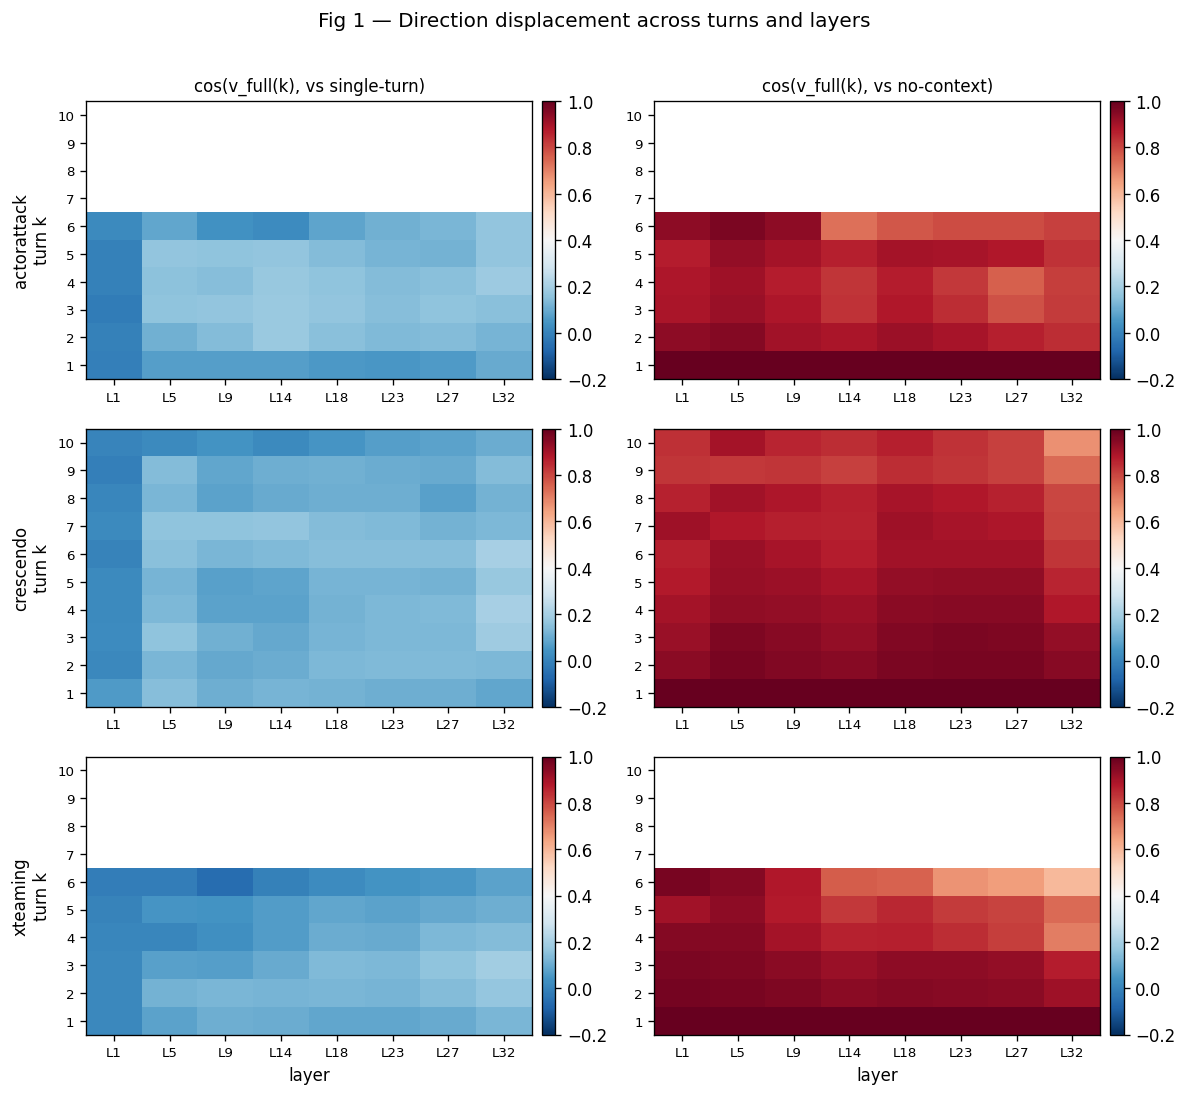

In [9]:
fig, axes = plt.subplots(len(avail_fw), 2, figsize=(10, 3.0 * len(avail_fw)), squeeze=False)

for row, fw in enumerate(avail_fw):
    # ── cos(v_full(k), v_ST) across layers
    m_vs_st = np.full((MAX_K, N_LAYERS_SWEEP), np.nan)
    for k in range(1, MAX_K + 1):
        v = v_full[fw].get(k)
        if v is None:
            continue
        for li in VERIFY_LAYERS:
            m_vs_st[k - 1, li] = cosine(v[li], v_st_inst[li])

    # ── cos(v_full(k), v_nc(k)) across layers
    m_vs_nc = np.full((MAX_K, N_LAYERS_SWEEP), np.nan)
    if fw in v_nc:
        for k in range(1, MAX_K + 1):
            v_f = v_full[fw].get(k)
            v_n = v_nc[fw].get(k)
            if v_f is None or v_n is None:
                continue
            for li in VERIFY_LAYERS:
                m_vs_nc[k - 1, li] = cosine(v_f[li], v_n[li])

    for col, (mat, title) in enumerate([(m_vs_st, 'vs single-turn'),
                                         (m_vs_nc, 'vs no-context')]):
        ax = axes[row, col]
        im = ax.imshow(mat, aspect='auto', vmin=-0.2, vmax=1.0, cmap='RdBu_r', origin='lower')
        ax.set_xticks(range(N_LAYERS_SWEEP))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.set_yticks(range(MAX_K))
        ax.set_yticklabels(range(1, MAX_K + 1), fontsize=8)
        if row == len(avail_fw) - 1:
            ax.set_xlabel('layer')
        if col == 0:
            ax.set_ylabel(f'{fw}\nturn k')
        if row == 0:
            ax.set_title(f'cos(v_full(k), {title})', fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

fig.suptitle('Fig 1 — Direction displacement across turns and layers', y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'clean_fig1_displacement.png')
plt.show()

## Fig 2 — §4.2a Detection AUROC (fixed vs adaptive)

Turn × layer heatmaps of test-split AUROC, two columns: fixed projection onto `v_ST`, adaptive projection onto `v_full(k)`. A defense anchored to the ST direction degrades across k and layers; recomputing per turn holds AUROC up.

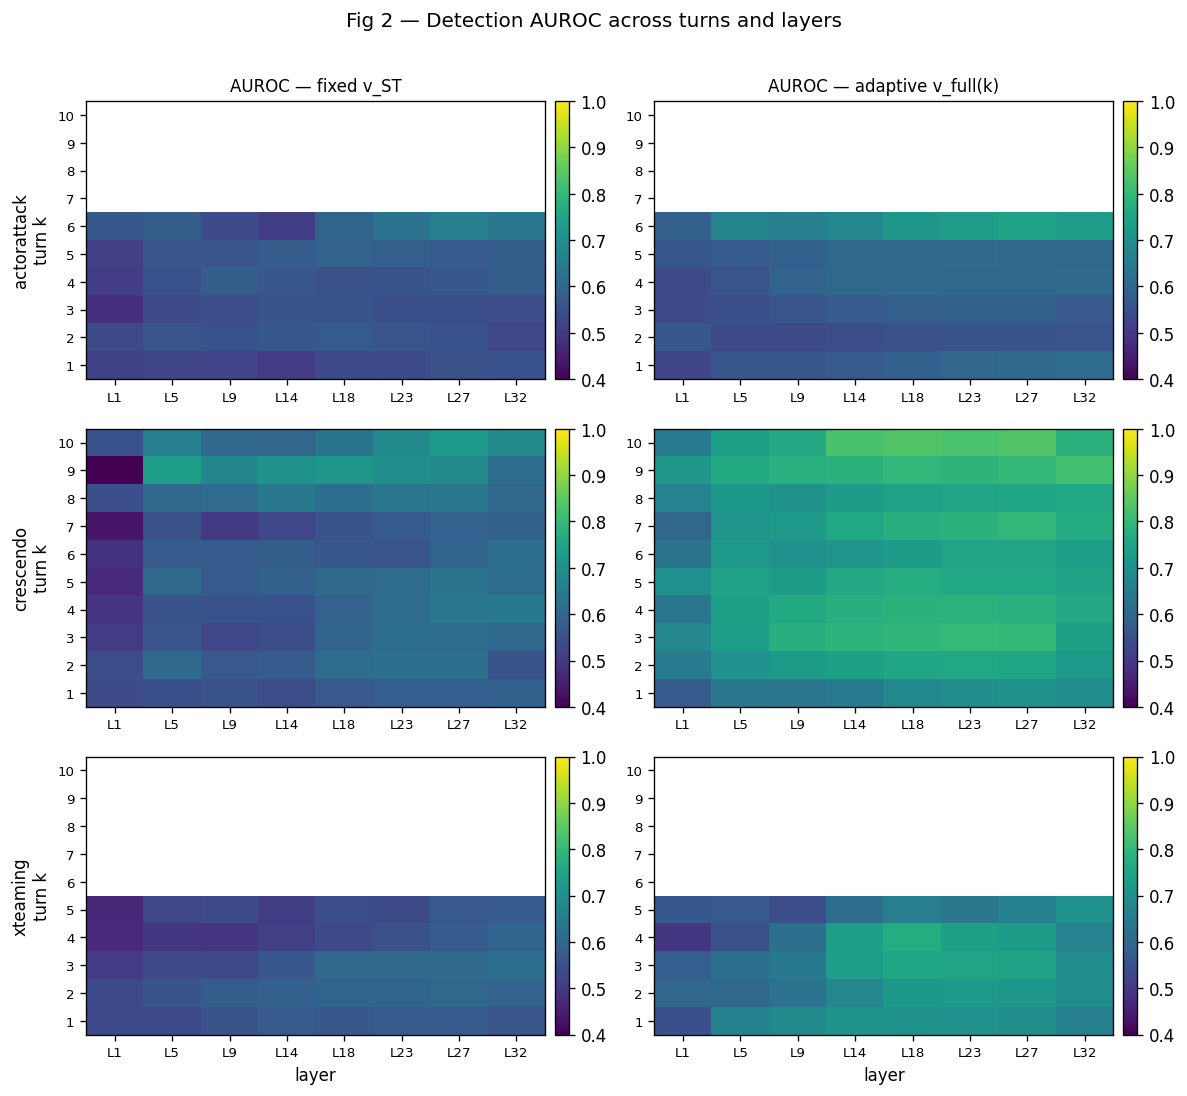

In [10]:
def auroc_at_k_layer(fw, direction_vec_by_layer, layer, k, use_adaptive=False):
    """Project test-split at (fw, k, layer) onto direction. `direction_vec_by_layer`:
    if use_adaptive=False, pass v_st_inst (shape L×D). If True, pass v_full[fw][k] (L×D)."""
    d_h = traj.get((fw, 'harmful'))
    d_b = traj.get((fw, 'benign'))
    if d_h is None or d_b is None or direction_vec_by_layer is None:
        return np.nan
    mh = (d_h['meta']['turn_k'] == k) & (d_h['meta']['data_split'] == 'test')
    mb = (d_b['meta']['turn_k'] == k) & (d_b['meta']['data_split'] == 'test')
    if mh.sum() < 5 or mb.sum() < 5:
        return np.nan
    h_h = d_h['h_inst'][mh.values, layer, :].astype(np.float32)
    h_b = d_b['h_inst'][mb.values, layer, :].astype(np.float32)
    v = direction_vec_by_layer[layer]
    proj = np.concatenate([h_h @ v, h_b @ v])
    y    = np.concatenate([np.ones(len(h_h)), np.zeros(len(h_b))])
    return roc_auc_score(y, proj)

fig, axes = plt.subplots(len(avail_fw), 2, figsize=(10, 3.0 * len(avail_fw)), squeeze=False)

for row, fw in enumerate(avail_fw):
    m_fixed    = np.full((MAX_K, N_LAYERS_SWEEP), np.nan)
    m_adaptive = np.full((MAX_K, N_LAYERS_SWEEP), np.nan)

    for k in range(1, MAX_K + 1):
        v_k = v_full[fw].get(k)
        for li in VERIFY_LAYERS:
            m_fixed[k - 1, li]    = auroc_at_k_layer(fw, v_st_inst, li, k)
            if v_k is not None:
                m_adaptive[k - 1, li] = auroc_at_k_layer(fw, v_k,       li, k)

    for col, (mat, title) in enumerate([(m_fixed, 'fixed v_ST'),
                                         (m_adaptive, 'adaptive v_full(k)')]):
        ax = axes[row, col]
        im = ax.imshow(mat, aspect='auto', vmin=0.4, vmax=1.0, cmap='viridis', origin='lower')
        ax.set_xticks(range(N_LAYERS_SWEEP))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.set_yticks(range(MAX_K))
        ax.set_yticklabels(range(1, MAX_K + 1), fontsize=8)
        if row == len(avail_fw) - 1:
            ax.set_xlabel('layer')
        if col == 0:
            ax.set_ylabel(f'{fw}\nturn k')
        if row == 0:
            ax.set_title(f'AUROC — {title}', fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

fig.suptitle('Fig 2 — Detection AUROC across turns and layers', y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'clean_fig2_detection.png')
plt.show()

## Fig 3 — §4.2b Linearity: MLP ≈ logistic within, both fail cross-condition

Across all layers (x-axis):
- **Within full-context:** AUROC for logistic vs MLP trained and tested on full-context at final turn. If they match, signal is linear — no hidden nonlinear structure for a defender to exploit.
- **Cross-condition ST → full-context:** AUROC for logistic vs MLP trained on single-turn, tested on full-context final turn. If both fall to chance, the multi-turn representation is structurally different — not a linear rotation that a more powerful model can see through.

Frameworks pooled (harmful + benign concatenated across all 3 frameworks) for a single clean panel. Final-turn used as the "most displaced" test case.

  L1     within log=0.849 mlp=0.869   cross log=0.582 mlp=0.525
  L5     within log=0.856 mlp=0.874   cross log=0.546 mlp=0.532
  L9     within log=0.850 mlp=0.895   cross log=0.544 mlp=0.548
  L14    within log=0.857 mlp=0.920   cross log=0.593 mlp=0.582
  L18    within log=0.886 mlp=0.918   cross log=0.619 mlp=0.581
  L23    within log=0.882 mlp=0.919   cross log=0.617 mlp=0.583
  L27    within log=0.861 mlp=0.914   cross log=0.628 mlp=0.606
  L32    within log=0.866 mlp=0.921   cross log=0.624 mlp=0.589


/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_16638/3062723398.py:58: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, results['within_mlp'], 's-', color='#1f77b4', ls='--', alpha=0.7, label='within full-ctx · MLP')
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_16638/3062723398.py:60: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, results['cross_mlp'],  's-', color='#d62728', ls='--', alpha=0.7, label='ST→full-ctx · MLP')


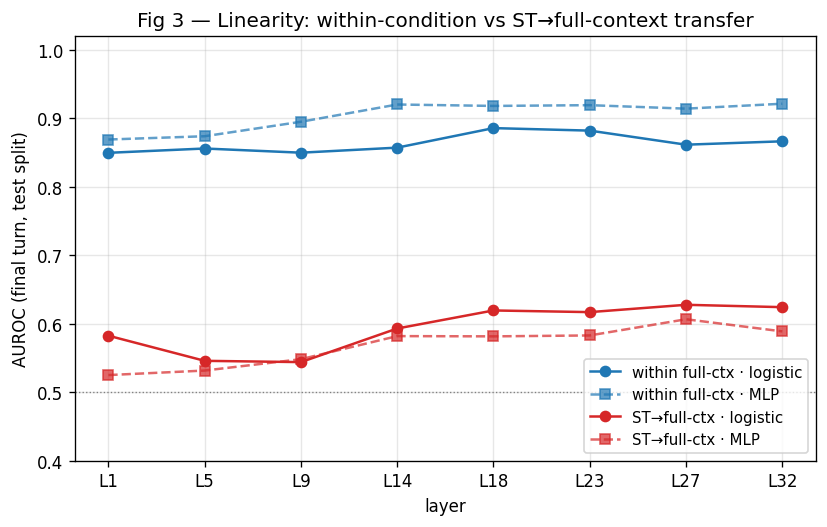

In [11]:
def get_final_turn_idx(data):
    m = data['meta']
    return m.groupby('conversation_id')['turn_k'].idxmax().values

def build_full_context_final(split_name, layer):
    """Concatenate final-turn h_inst across all frameworks (train or test)."""
    Xs, ys = [], []
    for fw in avail_fw:
        for cls, label in [('harmful', 1), ('benign', 0)]:
            d = traj.get((fw, cls))
            if d is None:
                continue
            idx_final = get_final_turn_idx(d)
            m_final = d['meta'].loc[idx_final]
            mask = (m_final['data_split'] == split_name).values
            sel = idx_final[mask]
            Xs.append(d['h_inst'][sel, layer, :].astype(np.float32))
            ys.append(np.full(mask.sum(), label))
    return np.concatenate(Xs, 0), np.concatenate(ys, 0)

def build_st(layer):
    Xh = st['harmful']['h_inst'][:, layer, :].astype(np.float32)
    Xb = st['benign']['h_inst'][:, layer, :].astype(np.float32)
    X  = np.concatenate([Xh, Xb], 0)
    y  = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))])
    return X, y

def train_eval(X_tr, y_tr, X_te, y_te, kind):
    if kind == 'logistic':
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
    else:
        clf = make_pipeline(StandardScaler(),
                             MLPClassifier(hidden_layer_sizes=(64,), max_iter=200,
                                            early_stopping=True, random_state=0))
    clf.fit(X_tr, y_tr)
    return roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

results = {k: np.full(N_LAYERS_SWEEP, np.nan) for k in
           ['within_log', 'within_mlp', 'cross_log', 'cross_mlp']}

for li in VERIFY_LAYERS:
    # within-condition: full-context train → full-context test
    Xtr, ytr = build_full_context_final('train', li)
    Xte, yte = build_full_context_final('test',  li)
    results['within_log'][li] = train_eval(Xtr, ytr, Xte, yte, 'logistic')
    results['within_mlp'][li] = train_eval(Xtr, ytr, Xte, yte, 'mlp')

    # cross-condition: ST train → full-context test
    Xst, yst = build_st(li)
    results['cross_log'][li] = train_eval(Xst, yst, Xte, yte, 'logistic')
    results['cross_mlp'][li] = train_eval(Xst, yst, Xte, yte, 'mlp')
    print(f'  {VERIFY_LABELS[li]:<5}  within log={results["within_log"][li]:.3f} mlp={results["within_mlp"][li]:.3f}   '
          f'cross log={results["cross_log"][li]:.3f} mlp={results["cross_mlp"][li]:.3f}')

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
x = np.arange(N_LAYERS_SWEEP)
ax.plot(x, results['within_log'], 'o-', color='#1f77b4', label='within full-ctx · logistic')
ax.plot(x, results['within_mlp'], 's-', color='#1f77b4', ls='--', alpha=0.7, label='within full-ctx · MLP')
ax.plot(x, results['cross_log'],  'o-', color='#d62728', label='ST→full-ctx · logistic')
ax.plot(x, results['cross_mlp'],  's-', color='#d62728', ls='--', alpha=0.7, label='ST→full-ctx · MLP')
ax.axhline(0.5, color='gray', ls=':', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(VERIFY_LABELS)
ax.set_xlabel('layer')
ax.set_ylabel('AUROC (final turn, test split)')
ax.set_ylim(0.4, 1.02)
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='lower right')
ax.set_title('Fig 3 — Linearity: within-condition vs ST→full-context transfer')
fig.tight_layout()
fig.savefig(FIG_DIR / 'clean_fig3_linearity.png')
plt.show()

## Fig 4 — §4.3 Token-position collapse

AUROC across layers for four probes: `{t_inst, t_post} × {harmfulness, refusal}`. Two panels compare:
- **Left — single-turn:** Zhao et al. prediction: `t_inst` > `t_post` on harmfulness; `t_post` > `t_inst` on refusal.
- **Right — full-context final turn:** separation collapses; both positions perform similarly on both tasks.

Refusal task is defined on harmful conversations only (refused vs. accepted, using `aisi_jailbroken`). Pooled across frameworks for simplicity.

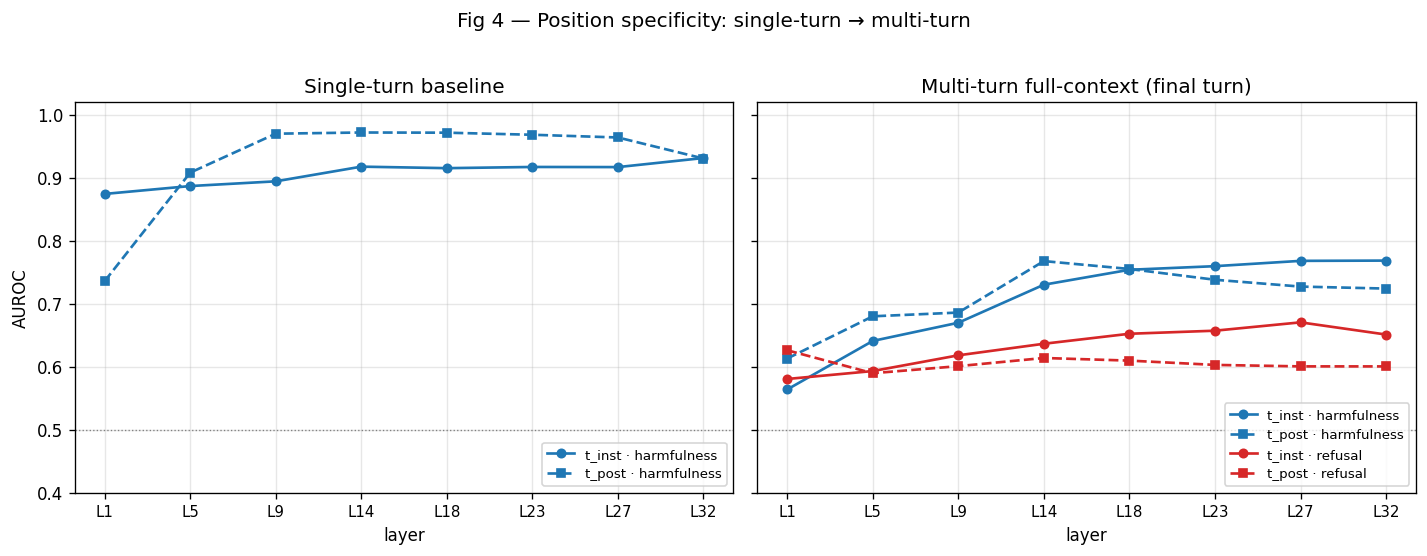

In [12]:
def harmfulness_auroc_st(h_key, layer):
    Xh = st['harmful'][h_key][:, layer, :].astype(np.float32)
    Xb = st['benign'][h_key][:, layer, :].astype(np.float32)
    d_direction = Xh.mean(0) - Xb.mean(0)
    d_direction /= np.linalg.norm(d_direction) + 1e-12
    proj = np.concatenate([Xh @ d_direction, Xb @ d_direction])
    y    = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))])
    return roc_auc_score(y, proj)

def harmfulness_auroc_fc(h_key, layer):
    """Pooled final-turn harmful vs benign across frameworks (test split)."""
    Xh, Xb = [], []
    for fw in avail_fw:
        for cls, bucket in [('harmful', Xh), ('benign', Xb)]:
            d = traj.get((fw, cls))
            if d is None:
                continue
            idx = get_final_turn_idx(d)
            m = d['meta'].loc[idx]
            mask_tr = (m['data_split'] == 'train').values
            mask_te = (m['data_split'] == 'test').values
            bucket.append({'train': d[h_key][idx[mask_tr], layer, :].astype(np.float32),
                           'test':  d[h_key][idx[mask_te], layer, :].astype(np.float32)})
    tr_h = np.concatenate([b['train'] for b in Xh], 0)
    tr_b = np.concatenate([b['train'] for b in Xb], 0)
    te_h = np.concatenate([b['test']  for b in Xh], 0)
    te_b = np.concatenate([b['test']  for b in Xb], 0)
    d_direction = tr_h.mean(0) - tr_b.mean(0)
    d_direction /= np.linalg.norm(d_direction) + 1e-12
    proj = np.concatenate([te_h @ d_direction, te_b @ d_direction])
    y    = np.concatenate([np.ones(len(te_h)), np.zeros(len(te_b))])
    return roc_auc_score(y, proj)

def refusal_auroc_st(h_key, layer):
    return np.nan  # undefined — no refusal labels on ST single-prompt baseline

def refusal_auroc_fc(h_key, layer):
    """Refused (1) vs accepted (0) within harmful conversations, final turn, pooled."""
    Xs, ys = [], []
    for fw in avail_fw:
        d = traj.get((fw, 'harmful'))
        if d is None or SUCCESS_COL not in d['meta'].columns:
            continue
        idx = get_final_turn_idx(d)
        m = d['meta'].loc[idx].reset_index(drop=True)
        lab = m[SUCCESS_COL]
        keep = lab.notna().values
        if keep.sum() < 10:
            continue
        sel = idx[keep]
        Xs.append(d[h_key][sel, layer, :].astype(np.float32))
        # y = 1 for refused (aisi_jailbroken == False), 0 for accepted
        ys.append((~lab[keep].astype(bool).values).astype(int))
    if not Xs:
        return np.nan
    X = np.concatenate(Xs, 0)
    y = np.concatenate(ys, 0)
    if y.sum() < 5 or (1 - y).sum() < 5:
        return np.nan
    # direction: refused - accepted
    d_direction = X[y == 1].mean(0) - X[y == 0].mean(0)
    d_direction /= np.linalg.norm(d_direction) + 1e-12
    proj = X @ d_direction
    return roc_auc_score(y, proj)

R = {panel: {task_pos: np.full(N_LAYERS_SWEEP, np.nan) for task_pos in
             [('harm', 'h_inst'), ('harm', 'h_post'), ('ref', 'h_inst'), ('ref', 'h_post')]}
     for panel in ['st', 'fc']}

for li in VERIFY_LAYERS:
    R['st'][('harm', 'h_inst')][li] = harmfulness_auroc_st('h_inst', li)
    R['st'][('harm', 'h_post')][li] = harmfulness_auroc_st('h_post', li)
    R['fc'][('harm', 'h_inst')][li] = harmfulness_auroc_fc('h_inst', li)
    R['fc'][('harm', 'h_post')][li] = harmfulness_auroc_fc('h_post', li)
    R['fc'][('ref',  'h_inst')][li] = refusal_auroc_fc('h_inst', li)
    R['fc'][('ref',  'h_post')][li] = refusal_auroc_fc('h_post', li)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(N_LAYERS_SWEEP)
panel_titles = {'st': 'Single-turn baseline', 'fc': 'Multi-turn full-context (final turn)'}
styles = {('harm', 'h_inst'): ('#1f77b4', '-',  'o', 't_inst · harmfulness'),
          ('harm', 'h_post'): ('#1f77b4', '--', 's', 't_post · harmfulness'),
          ('ref',  'h_inst'): ('#d62728', '-',  'o', 't_inst · refusal'),
          ('ref',  'h_post'): ('#d62728', '--', 's', 't_post · refusal')}

for ax, panel in zip(axes, ['st', 'fc']):
    for (task, pos), vals in R[panel].items():
        if np.isnan(vals).all():
            continue
        c, ls, mk, lb = styles[(task, pos)]
        ax.plot(x, vals, color=c, ls=ls, marker=mk, label=lb, lw=1.6, ms=5)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(VERIFY_LABELS, fontsize=9)
    ax.set_xlabel('layer')
    ax.set_title(panel_titles[panel])
    ax.set_ylim(0.4, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
axes[0].set_ylabel('AUROC')
fig.suptitle('Fig 4 — Position specificity: single-turn → multi-turn', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'clean_fig4_position_collapse.png')
plt.show()

## Fig 5 — §4.4 Signal location (context vs message)

At each layer, fraction of refused_harmful samples whose `h_inst` is closer to the accepted_harmful centroid than to the benign centroid. Two lines per framework panel:
- **Full-context:** the model has the whole conversation.
- **No-context:** only the final attacker message, no history.

Framework-dependent claim: Crescendo (escalation) shows a large gap — context carries the harmfulness signal even on refused attacks. ActorAttack may not, because the harmful intent is distributed through role-play framing that reads benign at the message level.

Final-turn only (the turn at which the attack is resolved).

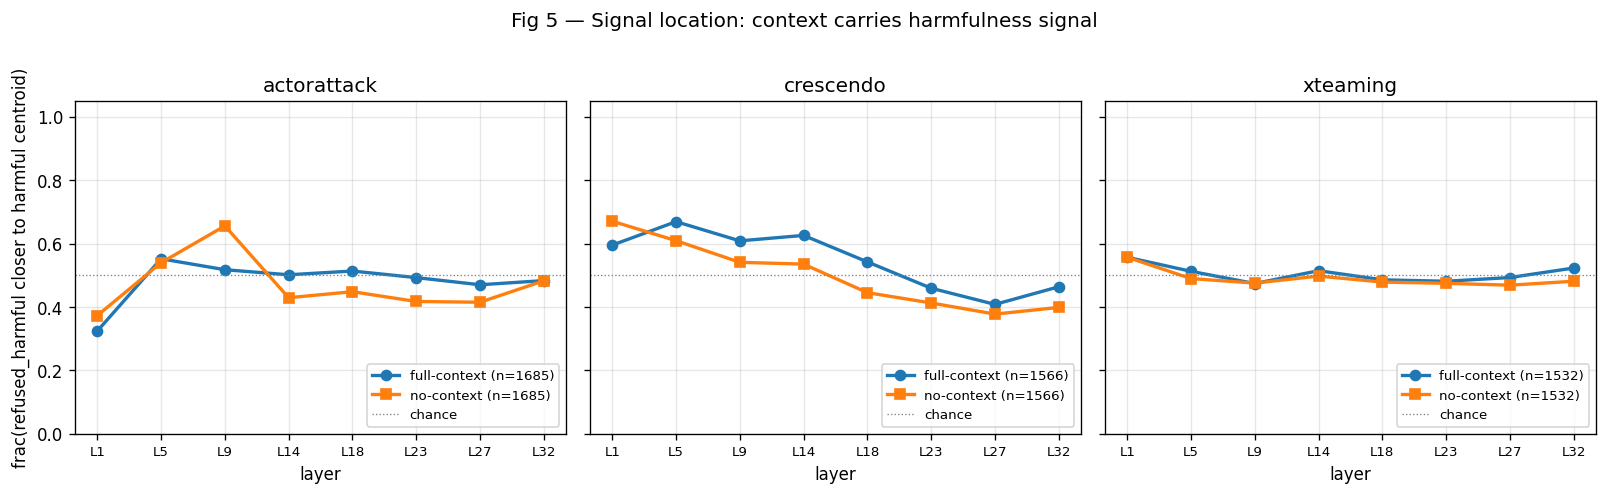

In [13]:
def nearest_centroid_fraction(data_dict, fw, h_key, layer):
    """Final-turn fraction of refused_harmful closer to accepted_harmful centroid than to benign centroid."""
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None or SUCCESS_COL not in d_h['meta'].columns:
        return np.nan, 0

    idx_final = get_final_turn_idx(d_h)
    m_h = d_h['meta'].loc[idx_final].reset_index(drop=True)
    lab = m_h[SUCCESS_COL]
    keep = lab.notna().values
    if keep.sum() < 10:
        return np.nan, 0
    h_final = d_h[h_key][idx_final[keep], layer, :].astype(np.float32)
    lab_keep = lab[keep].astype(bool).values
    h_acc = h_final[lab_keep]
    h_ref = h_final[~lab_keep]
    if len(h_acc) < 5 or len(h_ref) < 5:
        return np.nan, len(h_ref)

    idx_b_final = get_final_turn_idx(d_b)
    h_ben = d_b[h_key][idx_b_final, layer, :].astype(np.float32)
    if len(h_ben) < 5:
        return np.nan, len(h_ref)

    c_acc = h_acc.mean(0)
    c_ben = h_ben.mean(0)
    closer = (np.linalg.norm(h_ref - c_acc, axis=1) <
              np.linalg.norm(h_ref - c_ben, axis=1))
    return closer.mean(), len(h_ref)

fig, axes = plt.subplots(1, len(avail_fw), figsize=(4.5 * len(avail_fw), 4), sharey=True)
if len(avail_fw) == 1:
    axes = [axes]

x = np.arange(N_LAYERS_SWEEP)
for ax, fw in zip(axes, avail_fw):
    fc_frac = np.full(N_LAYERS_SWEEP, np.nan)
    nc_frac = np.full(N_LAYERS_SWEEP, np.nan)
    fc_n, nc_n = 0, 0
    for li in VERIFY_LAYERS:
        fc_frac[li], fc_n = nearest_centroid_fraction(traj, fw, 'h_inst', li)
        if fw in {k[0] for k in nc}:
            nc_frac[li], nc_n = nearest_centroid_fraction(nc, fw, 'h_inst', li)
    ax.plot(x, fc_frac, 'o-', color='#1f77b4', label=f'full-context (n={fc_n})', lw=2)
    if not np.isnan(nc_frac).all():
        ax.plot(x, nc_frac, 's-', color='#ff7f0e', label=f'no-context (n={nc_n})', lw=2)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8, label='chance')
    ax.set_xticks(x)
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_xlabel('layer')
    ax.set_title(fw)
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
axes[0].set_ylabel('frac(refused_harmful closer to harmful centroid)')

fig.suptitle('Fig 5 — Signal location: context carries harmfulness signal', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'clean_fig5_signal_location.png')
plt.show()

## Done

Five figures written to `figures/clean/`. Existing notebooks and their figures are untouched.